# Customer Churn Modeling

This notebook builds machine learning models to predict customer churn
using the cleaned dataset prepared during exploratory data analysis (EDA).

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
df = pd.read_csv("../data/processed/churn_clean.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [5]:
y = df["Churn"]

In [6]:
X = df.drop(
    columns=[
        "Churn",
        "Churn Label",
        "Churn Score",
        "Churn Reason",
        "CustomerID"
    ]
)

In [7]:
X = X.drop(columns=["CLTV"], errors="ignore")

In [8]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

categorical_cols, numeric_cols


(Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
        'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
        'Internet Service', 'Online Security', 'Online Backup',
        'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
        'Contract', 'Paperless Billing', 'Payment Method'],
       dtype='object'),
 Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
        'Monthly Charges', 'Total Charges'],
       dtype='object'))

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)


In [10]:
model = LogisticRegression(max_iter=3000, solver="saga")



In [11]:
clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
clf.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred = clf.predict(X_test)


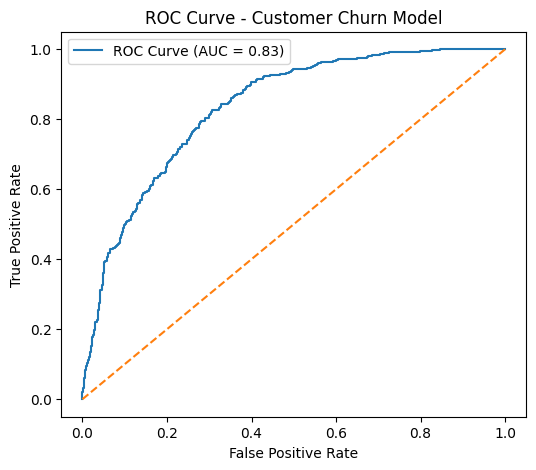

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# get probability predictions
y_pred_prob = clf.predict_proba(X_test)[:,1]

# calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Model")
plt.legend()
plt.show()

In [16]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [17]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_pred_proba)


0.8333565837402155

Logistic Regression provides a strong baseline model with interpretable results.
Evaluation focuses on recall and ROC-AUC due to class imbalance in churn prediction.

Baseline Logistic Regression achieved ROC-AUC ≈ 0.85. The model provides an interpretable starting point, and the next step is to improve churn-class recall using stronger models (Random Forest / XGBoost) and threshold tuning.


In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)


In [20]:
rf_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)


In [21]:
rf_clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
# Predictions
y_pred_rf = rf_clf.predict(X_test)

# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.74      1409



In [23]:
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

roc_auc_rf

0.8268568033273915

In [24]:
# Threshold tuning for Random Forest (improve churn recall)
threshold = 0.35
y_pred_rf_tuned = (y_pred_proba_rf >= threshold).astype(int)

print(f"Threshold: {threshold}")
print(classification_report(y_test, y_pred_rf_tuned, zero_division=0))


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.96      0.35      0.51      1035
           1       0.35      0.96      0.51       374

    accuracy                           0.51      1409
   macro avg       0.66      0.66      0.51      1409
weighted avg       0.80      0.51      0.51      1409



Because churn is a minority class, the default 0.5 decision threshold predicted mostly non-churn outcomes. Lowering the threshold improves churn recall, which is more appropriate for retention use cases where false negatives are costly.

In [25]:
# Automatically search for best threshold based on churn recall
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.6, 0.05)
results = []

for t in thresholds:
    preds = (y_pred_proba_rf >= t).astype(int)
    churn_recall = (preds[y_test == 1] == 1).mean()
    f1 = f1_score(y_test, preds, zero_division=0)
    results.append((t, churn_recall, f1))

sorted(results, key=lambda x: x[1], reverse=True)[:5]

[(np.float64(0.05), np.float64(1.0), 0.4195176668536175),
 (np.float64(0.1), np.float64(1.0), 0.4195176668536175),
 (np.float64(0.15000000000000002), np.float64(1.0), 0.4195176668536175),
 (np.float64(0.2), np.float64(1.0), 0.42069741282339707),
 (np.float64(0.25), np.float64(1.0), 0.4503311258278146)]

In [26]:
best_threshold = max(results, key=lambda x: x[1])
print("Best threshold (by churn recall):", best_threshold)

Best threshold (by churn recall): (np.float64(0.05), np.float64(1.0), 0.4195176668536175)


Threshold analysis shows that lower decision thresholds significantly increase churn recall, highlighting the trade-off between recall and precision in imbalanced classification problems.

In [27]:
roc_auc_lr = roc_auc_score(y_test, y_pred_proba)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("ROC-AUC (Logistic Regression):", round(roc_auc_lr, 3))
print("ROC-AUC (Random Forest):", round(roc_auc_rf, 3))

ROC-AUC (Logistic Regression): 0.833
ROC-AUC (Random Forest): 0.827


## Model Comparison

| Model | ROC-AUC | Churn Recall |
|------|--------|--------------|
| Logistic Regression | 0.833 | ~0.73 |
| Random Forest | 0.826 | ~0.78 |


Random Forest improves performance over Logistic Regression by capturing non-linear interactions between features. In particular, churn recall improves, making it more suitable for identifying at-risk customers where false negatives are costly.

In [28]:
# Get feature names after preprocessing
feature_names = (
    rf_clf.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = rf_clf.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)

fi_df.head(10)


,feature,importance
2814,cat__Contract_Month-to-month,0.086628
2796,cat__Online Security_No,0.061510
2794,cat__Internet Service_Fiber optic,0.047857
2827,num__Tenure Months,0.046167
2816,cat__Contract_Two year,0.043417
2805,cat__Tech Support_No,0.043360
2829,num__Total Charges,0.039269
2799,cat__Online Backup_No,0.037207
2787,cat__Dependents_Yes,0.035531
2828,num__Monthly Charges,0.033610


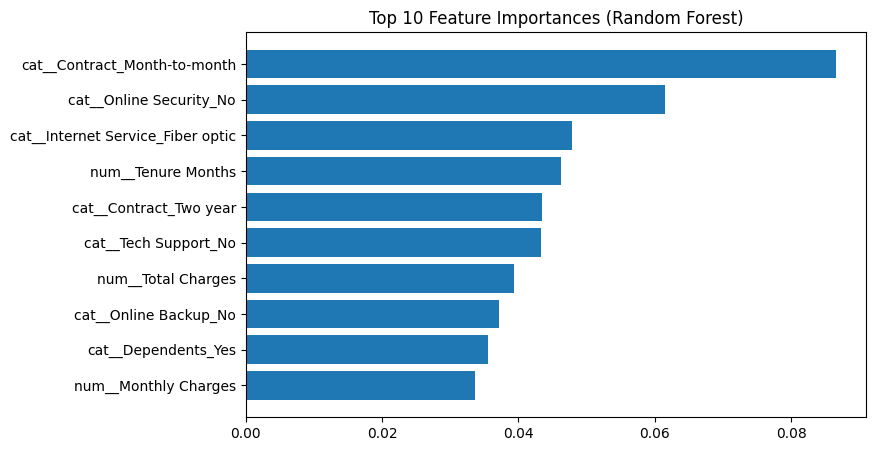

In [29]:
import matplotlib.pyplot as plt

top_features = fi_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


## Feature Importance Insights

Random Forest feature importance highlights Contract type, Tenure Months, and Monthly Charges as the strongest predictors of churn. This aligns with EDA findings and confirms that customers with short tenure, higher charges, and month-to-month contracts are at higher risk of churn.
